# Шаг 0. Установка зависимостей

In [1]:
!pip install sentence-transformers scikit-learn numpy pandas matplotlib

# Шаг 1. Загрузка данных и моделей

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE

print('✓ Все библиотеки импортированы')

c:\Users\Алексей\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Все библиотеки импортированы


In [3]:
# Загрузка данных
with open("code_corpus.json", encoding="utf-8") as f:
    corpus = json.load(f)

with open("eval_questions.json", encoding="utf-8") as f:
    questions = json.load(f)

with open("categories.json", encoding="utf-8") as f:
    categories = json.load(f)["categories"]

print(f"Корпус функций: {len(corpus)}")
print(f"Тестовых вопросов: {len(questions)}")
print(f"Категорий: {len(categories)}")

# Проверка целостности данных
## 1 - правильное количество записей
assert len(corpus) == 200, f"Ожидалось 200 функций. Загружено {len(corpus)}"
assert len(questions) == 25, f"Ожидалось 25 вопросов. Загружено {len(questions)}"
assert len(categories) == 5, f"Ожидалось 5 категорий. Загружено {len(categories)}"

## 2 - нет дублирующиеся id
all_ids = [f["id"] for f in corpus]
assert len(all_ids) == len(set(all_ids)), "Есть дублирующиеся id"

## 3 - все эталонные ответы есть в корпусе
corpus_ids_set = set(all_ids)
for q in questions:
    assert q["correct_chunk_id"] in corpus_ids_set, f"{q['correct_chunk_id']} нет в корпусе"
    
print("✓ Все проверки целостности пройдены")

Корпус функций: 200
Тестовых вопросов: 25
Категорий: 5
✓ Все проверки целостности пройдены


In [4]:
# Выбор двух моделей 
## Модель 1: paraphrase-multilingual-MiniLM-L12-v2
#   - быстрая, мало весит, размерность вектора 384 числа
#   - менее точная
## Модель 2: paraphrase-multilingual-mpnet-base-v2
#   - медленная, больше весит, размерность вектора 768 числа
#   - точнее

models = [
    ("paraphrase-multilingual-MiniLM-L12-v2", "MiniLM-L12 (быстрая)"),
    ("paraphrase-multilingual-mpnet-base-v2",  "MPNet-base (мощная)"),
]

print("Модели для сравнения:")
for name, label in models:
    print(f" - {label}: {name}")

Модели для сравнения:
 - MiniLM-L12 (быстрая): paraphrase-multilingual-MiniLM-L12-v2
 - MPNet-base (мощная): paraphrase-multilingual-mpnet-base-v2


# Шаг 2. Генерация эмбеддингов и поиск

In [5]:
# Подготовка текстов корпуса(описание + коды функций) для передачи в модель
corpus_texts = [f"{f['description']}\n{f['code']}" for f in corpus]

def cosine_similarity(a, b_matrix):
    """
    Вычисляет косинусное сходство вектора a
    со всеми строками матрицы b_matrix
    """
    a_norm = a / np.linalg.norm(a)
    b_norm = b_matrix / np.linalg.norm(b_matrix, axis = 1, keepdims = True)
    return np.dot(b_norm, a_norm)

def model_evaluation(model_name, label, corpus_texts, corpus_ids, questions):
    """
    Загружает модель, генерирует векторы корпуса,
    для каждого вопроса ищет топ-3 похожих функций, 
    вычисляет Precision@3 и MRR
    """
    print(f"Модель: {label}")
    t0 = time.time()
    model = SentenceTransformer(model_name)
    print(f"✓ Модель загружена за {time.time() - t0:.1f} секунд")

    t1 = time.time()
    embeddings = model.encode(
        corpus_texts,
        batch_size=32,
        convert_to_numpy=True
    )
    print(f"✓ {len(embeddings)} векторов сгенерировано за {time.time() - t1:.1f} секунд")
    print(f"Размерность вектора: {embeddings.shape[1]}")

    hits_p3 = 0
    rr_list = []
    rows = []

    for q in questions:
        # Кодируем вопрос в вектор
        q_emb = model.encode([q["query"]], convert_to_numpy=True)[0]
        # Считаем сходство вопроса с функциями
        sims = cosine_similarity(q_emb, embeddings)
        
        # Находим топ-3
        ranked = np.argsort(sims)[::-1]
        top3_ids = [corpus_ids[i] for i in ranked[:3]]
        top3_sims = [sims[i] for i in ranked[:3]]

        # Проверяем попал ли правильный ответ в топ-3
        correct = q["correct_chunk_id"]
        in_top3 = correct in top3_ids
 
        # Ищем ранг правильного ответа
        rank = None
        for i, idx in enumerate(ranked):
            if corpus_ids[idx] == correct:
                rank = i + 1
                break
        
        rr = 1 / rank if rank else 0

        rr_list.append(rr)
        if in_top3:
            hits_p3 += 1

        rows.append({
            "question_id" : q["question_id"],
            "query"       : q["query"],
            "lang"        : q["language"],
            "correct"     : correct,
            "top1"        : top3_ids[0],
            "top2"        : top3_ids[1],
            "top3"        : top3_ids[2],
            "in_top3"     : in_top3,
            "rank"        : rank,
            "rr"          : round(rr, 4),
            "sim_top1"    : round(float(top3_sims[0]), 4),
        })
        
    precision3 = hits_p3 / len(questions)
    mrr = sum(rr_list) / len(rr_list)

    print(f"\n Результаты:")
    print(f"Precision@3 = {precision3:.4f}  ({hits_p3}/{len(questions)})")
    print(f"MRR         = {mrr:.4f}\n")

    return {
        "model_name" : model_name,
        "label"      : label,
        "precision3" : precision3,
        "mrr"        : mrr,
        "hits"       : hits_p3,
        "total"      : len(questions),
        "embeddings" : embeddings,
        "details"    : pd.DataFrame(rows),
        "dim"        : embeddings.shape[1],
    }


In [6]:
results = {}

for name, label in models:
    result = model_evaluation(
        model_name   = name,
        label        = label,
        corpus_texts = corpus_texts,
        corpus_ids   = all_ids,
        questions    = questions
    )
    results[name] = result

print("\n✓ Оценка моделей завершена")

Модель: MiniLM-L12 (быстрая)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8685.31it/s]


✓ Модель загружена за 8.9 секунд
✓ 200 векторов сгенерировано за 4.8 секунд
Размерность вектора: 384

 Результаты:
Precision@3 = 0.8000  (20/25)
MRR         = 0.5621

Модель: MPNet-base (мощная)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9974.15it/s]


✓ Модель загружена за 8.7 секунд
✓ 200 векторов сгенерировано за 18.8 секунд
Размерность вектора: 768

 Результаты:
Precision@3 = 0.8000  (20/25)
MRR         = 0.5364


✓ Оценка моделей завершена


# Шаг 3. Метрика и визуализация 

In [7]:
# Сводная таблица сравнения моделей
summary_rows = []
for mname, res in results.items():
    summary_rows.append({
        "Модель": res["label"],
        "Precision@3": f"{res['precision3']:.4f}",
        "MRR": f"{res['mrr']:.4f}",
        "Попаданий в топ-3": f"{res['hits']}/{res['total']}",
    })

df_summary = pd.DataFrame(summary_rows)
print("\n Сравнительная таблица:")
print(df_summary.to_string(index=False))

## Лучшая модель по Precision@3
def get_precision(k):
    return results[k]['precision3']

best_name = max(results, key=get_precision)
best = results[best_name]

print(f"\n Лучшая модель: {best['label']}  (Precision@3 = {best['precision3']:.4f})")


 Сравнительная таблица:
              Модель Precision@3    MRR Попаданий в топ-3
MiniLM-L12 (быстрая)      0.8000 0.5621             20/25
 MPNet-base (мощная)      0.8000 0.5364             20/25

 Лучшая модель: MiniLM-L12 (быстрая)  (Precision@3 = 0.8000)


In [ ]:
# Двумерная проекция эмбеддингов лучшей модели
tsne = TSNE(n_components=2, random_state=42, max_iter=1000)
coords = tsne.fit_transform(best['embeddings'])

print(f"✓ Готово: {coords.shape}")

Строим t-SNE для модели 'MiniLM-L12 (быстрая)'...
✓ Готово: (200, 2)


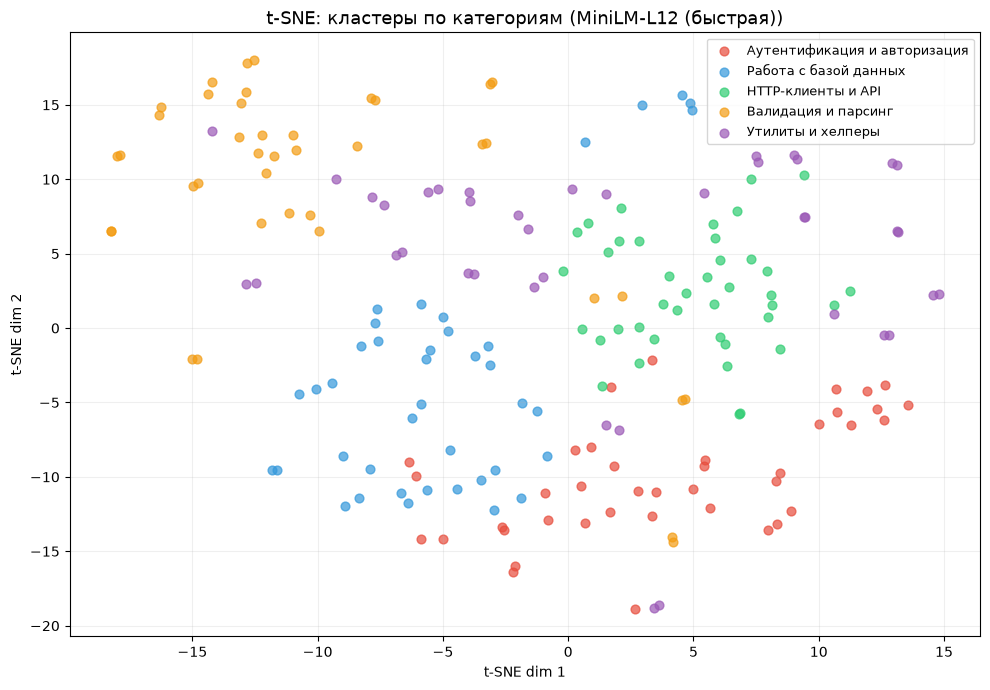

✓ График сохранен: tsne.png


In [9]:
# Цвета и названия категорий
cat_colors = {c["key"]: c["color"] for c in categories}
cat_labels = {c["key"]: c["label"] for c in categories}

# Категория каждой функции
cats = [f["category"] for f in corpus]

fig, ax = plt.subplots(figsize=(10, 7))

for cat_key in cat_colors:
    mask = np.array([c == cat_key for c in cats])
    x = coords[mask, 0]
    y = coords[mask, 1]
    ax.scatter(x, y, c=cat_colors[cat_key], label=cat_labels[cat_key], alpha=0.7, s=40)

ax.set_title(f"t-SNE: кластеры по категориям ({best['label']})", fontsize=13)
ax.set_xlabel("t-SNE dim 1")
ax.set_ylabel("t-SNE dim 2")
ax.legend(loc="best", fontsize=9)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("tsne.png", dpi=150)
plt.show()
print("✓ График сохранен: tsne.png")

# Вывод

In [ ]:
conclusion = (
    f"По результатам сравнения двух моделей лучшей оказалась «{best['label']}»\n"
    f"с Precision@3 = {best['precision3']:.4f} и MRR = {best['mrr']:.4f}.\n"
    f"Она точнее находит нужные функции по текстовому запросу,\n"
    f"так как имеет большую размерность вектора ({best['dim']} чисел),\n"
    f"что позволяет лучше улавливать смысл запроса.\n"
    f"На графике t-SNE видно, что функции одной тематики группируются вместе,\n"
    f"это подтверждает качество модели."
)

print(conclusion)

with open("conclusion.txt", "w", encoding="utf-8") as f:
    f.write(conclusion)

print("✓ Вывод сохранён в conclusion.txt")

По результатам сравнения двух моделей лучшей оказалась «MiniLM-L12 (быстрая)»
с Precision@3 = 0.8000 и MRR = 0.5621.
Она точнее находит нужные функции по текстовому запросу,
так как имеет большую размерность вектора (384 чисел),
что позволяет лучше улавливать смысл запроса.
На графике t-SNE видно, что функции одной тематики группируются вместе —
это подтверждает качество модели.
✓ Вывод сохранён в conclusion.txt
